# 0. Import

## 0.1 环境设置与本地模型加载

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
from mapanything.models import MapAnything
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MapAnything.from_pretrained(
    "/home/liu4000/Desktop/FS_Engine/onnx/MapAnything",
    local_files_only=True,
)

Loading pretrained dinov2_vitg14 from torch hub


Using cache found in /home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main


Loading weights from local directory


# 1. Prepare inputs — capture1 & capture2

读取两个采集的左图、标定和米制深度，生成 `views`、`processed_views` 和 `capture_info`。
校正、内参调整、深度清理和输入检查封装在 [ma_utils.py](ma_utils.py) 中。

输出尺寸为 **宽 518 × 高 434**，Tensor 保留在 CPU，供后续 `model.infer()` 使用。
预览展示预处理前的 **800×960** 图像与深度对齐情况。

## 1.1 输入路径与预处理尺寸配置

In [3]:
from pathlib import Path
import sys

# 支持从仓库根目录或 python/ 目录启动。
sys.path.insert(0, str(Path.cwd() / "python"))
from ma_utils import repository_root, prepare_inputs, show_input_views

REPO_ROOT = repository_root()
DATA_ROOT = REPO_ROOT / "data"
CAPTURE_NAMES = ("capture1", "capture2")
MA_RESIZE_MODE = "fixed_size"
MA_SIZE_WH = (518, 434)  # 宽、高

## 1.2 准备并检查 RGB、内参和深度

In [4]:
views, processed_views, capture_info = prepare_inputs(
    DATA_ROOT,
    CAPTURE_NAMES,
    resize_mode=MA_RESIZE_MODE,
    size=MA_SIZE_WH,
)

capture1: RGB=(800, 960, 3), depth=(800, 960), valid=48.8%, baseline=0.055307 m
  depth [p01, p50, p99] (m): [0.29878849 0.43176919 0.68080354]
  K on depth grid:
 [[591.4468    0.      487.10104]
 [  0.      589.1364  405.57352]
 [  0.        0.        1.     ]]
capture2: RGB=(800, 960, 3), depth=(800, 960), valid=47.6%, baseline=0.055307 m
  depth [p01, p50, p99] (m): [0.29528167 0.39132684 0.67892878]
  K on depth grid:
 [[591.4468    0.      487.10104]
 [  0.      589.1364  405.57352]
 [  0.        0.        1.     ]]
capture1: img=(1, 3, 434, 518), depth_z=(1, 434, 518), intrinsics=(1, 3, 3)
capture2: img=(1, 3, 434, 518), depth_z=(1, 434, 518), intrinsics=(1, 3, 3)


## 1.3 可视化 RGB、深度及对齐效果

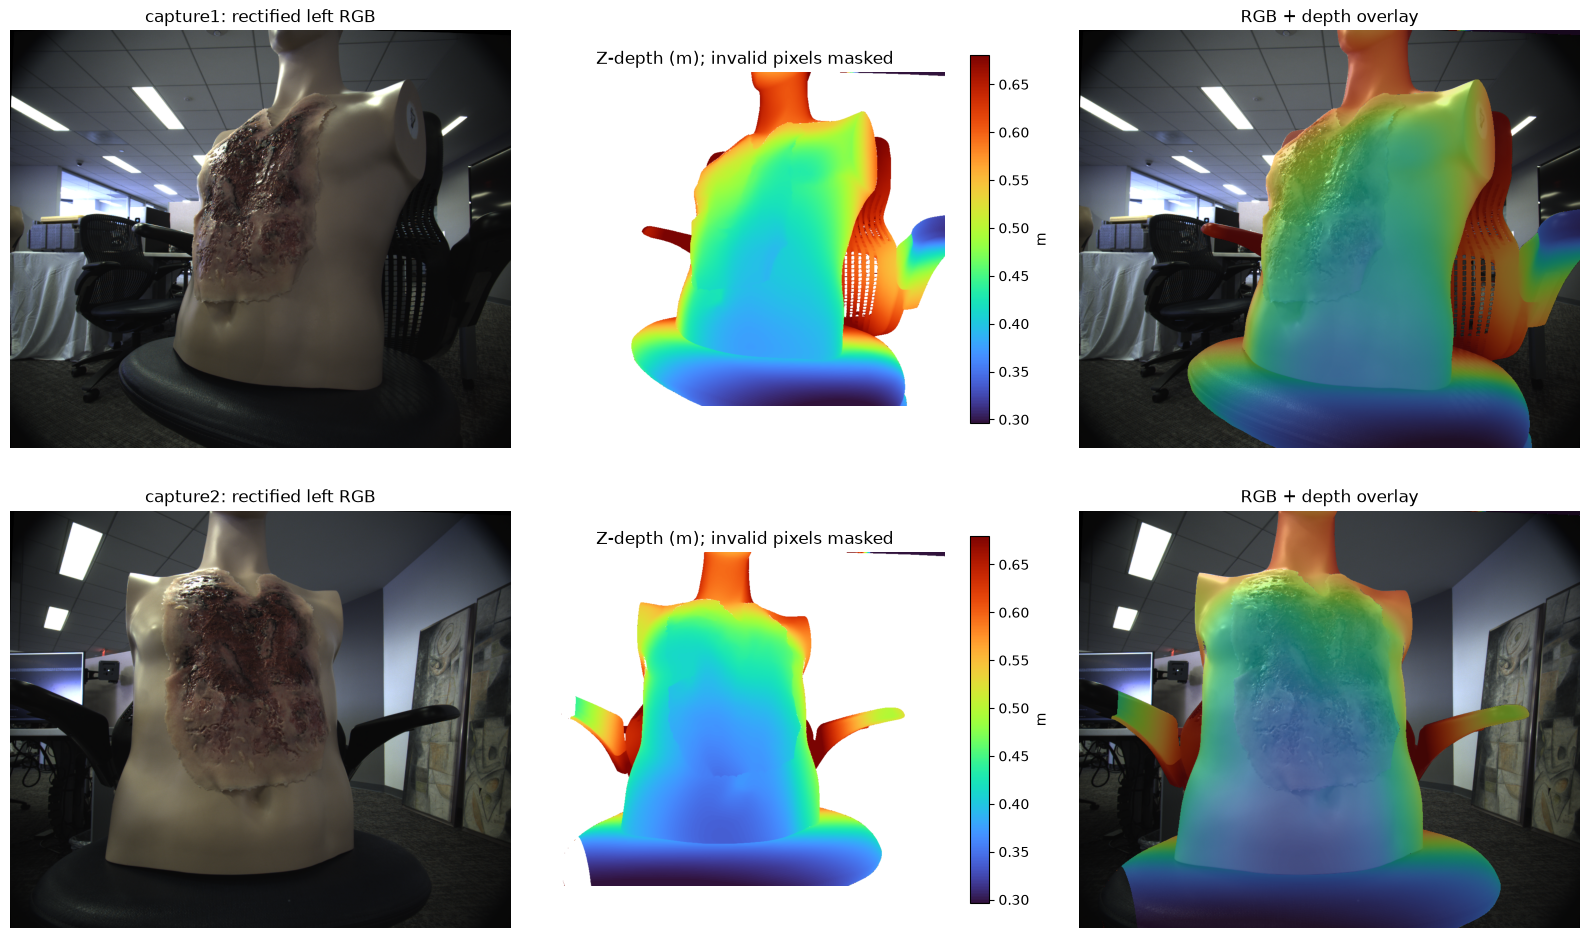

In [5]:
fig = show_input_views(views, CAPTURE_NAMES)

# 2. Inference

将 `capture1`、`capture2` 作为两个视角联合推理，使用 RGB、内参和米制深度。
模型移到 `device` 后，`model.infer()` 会自动将输入 Tensor 搬到同一设备，并在 inference mode 下运行。
`predictions` 按 `CAPTURE_NAMES` 的顺序返回每个视角的深度、三维点、相机位姿和有效掩码。
计时包含输入传输、模型计算和输出后处理，不包含模型搬到设备的时间。

## 2.1 设置模型设备与评估模式

In [6]:
from ma_utils import prepare_model_for_inference, inference_timer, summarize_predictions

model = prepare_model_for_inference(model, device)

Inference device: cuda (NVIDIA RTX PRO 4000 Blackwell)


## 2.2 联合推理与计时

In [7]:
with inference_timer(device):
    predictions = model.infer(
        processed_views,
        memory_efficient_inference=True,  # 减少 dense prediction heads 的显存占用
        minibatch_size=None,              # 自动选择；显存紧张时可设为 1
        use_amp=True,
        amp_dtype="bf16",
        apply_mask=True,
        mask_edges=True,
        apply_confidence_mask=False,
        confidence_percentile=10,         # 开启 confidence mask 时生效
        use_multiview_confidence=False,
        ignore_calibration_inputs=False,
        ignore_depth_inputs=False,
        ignore_pose_inputs=False,
        ignore_depth_scale_inputs=False,
        ignore_pose_scale_inputs=False,
    )

Inference completed in 0.697 s


## 2.3 检查预测结果

`predictions[0]` 对应 `capture1`，`predictions[1]` 对应 `capture2`。
`depth_z` 是米制 Z 深度，形状为 `(1, 434, 518, 1)`；`pts3d` 是共同坐标系中的三维点，形状为 `(1, 434, 518, 3)`。
下方统计仅使用输出 `mask` 中深度有限且大于零的像素。

In [8]:
prediction_summary = summarize_predictions(predictions, CAPTURE_NAMES, processed_views)

capture1: depth_z=(1, 434, 518, 1), device=cuda:0, valid=58.7%, median depth=0.4157 m
capture2: depth_z=(1, 434, 518, 1), device=cuda:0, valid=57.6%, median depth=0.3818 m


# 3. Merge meshes & save PLY

读取两次采集的原始 `mesh.ply`，通过 `inv(T1) @ T2` 将 capture2 转到 capture1 的校正后左相机坐标系，再合并保存。坐标单位为米。
使用上一章的 `predictions`，不重新推理。保留顶点颜色，原始文件不变；这里只拼接网格，不融合重叠表面。

In [9]:
from ma_utils import merge_capture_meshes, save_merged_mesh

MERGED_MESH_PATH = REPO_ROOT / "result" / "mapanything" / "capture1_capture2_merged.ply"

combined_mesh, T_2_to_1 = merge_capture_meshes(
    DATA_ROOT, predictions, CAPTURE_NAMES,
)
print("T_2_to_1:\n", T_2_to_1)

saved_mesh_path = save_merged_mesh(combined_mesh, MERGED_MESH_PATH)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Merged capture2 into capture1 coordinates (metres): 473,037 vertices, 939,139 triangles
T_2_to_1:
 [[ 0.7293789   0.03137613  0.68339008 -0.28154668]
 [-0.04045584  0.99917766 -0.00269639  0.00518859]
 [-0.6829127  -0.02568043  0.73004847  0.14360138]
 [ 0.          0.          0.          1.        ]]
Saved PLY: /home/liu4000/Desktop/FS_Engine/result/mapanything/capture1_capture2_merged.ply
